In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

In [6]:
ticker_input = input("Please enter the stock symbols (comma-separated, e.g., AAPL,MSFT,GOOGL): ")

In [7]:
# 1. 设置时间范围 (获取过去5年的数据)
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=365 * 5)

print(f"Data acquisition range: From {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}\n")

# 2. 定义想要分析的股票/指数代码 (Ticker)
tickers = [ticker.strip().upper() for ticker in ticker_input.split(",")]

# 3. 从 Yahoo Finance 下载数据
print("Downloading data from Yahoo Finance...")
df = yf.download(tickers, start=start_date, end=end_date)
df.head()

Data acquisition range: From 2021-06-15 to 2026-06-14



[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-06-15,126.366829,127.302597,126.123141,126.659257,62746300
2021-06-16,126.863991,127.585313,125.216672,127.078437,91815000
2021-06-17,128.462570,129.203391,126.376601,126.522823,96721700
2021-06-18,127.166168,128.189646,126.951722,127.409856,108953300
2021-06-21,128.959671,129.066894,125.947691,127.010167,79663300



--- First 5 Rows ---
Ticker            AAPL
Date                  
2021-06-15  126.366829
2021-06-16  126.863991
2021-06-17  128.462570
2021-06-18  127.166168
2021-06-21  128.959671


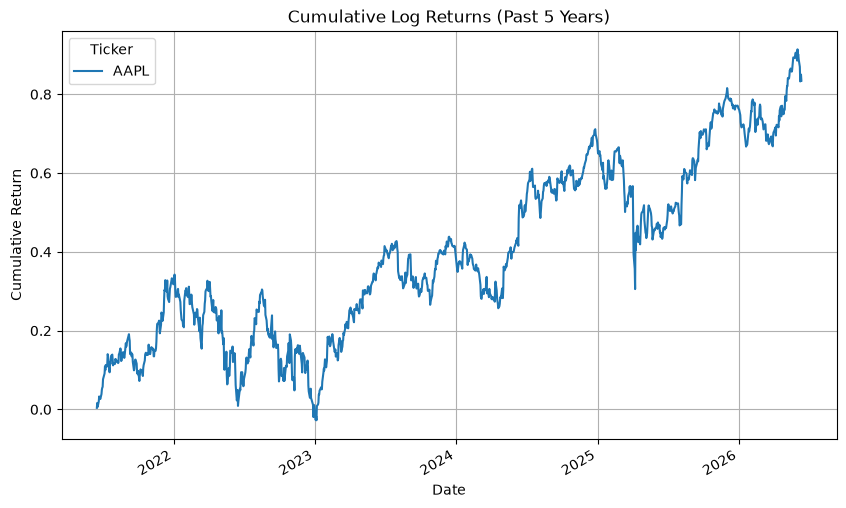

In [9]:
# 4. 提取调整后的收盘价 (Adjusted Close)

close = df["Close"]

print("\n--- First 5 Rows ---")
print(close.head())

# 5. 计算每日对数收益率 (Daily Log Returns)
log_returns = np.log(close / close.shift(1))

# 6. 计算累计对数收益率 (Cumulative Log Returns)
cum_log_returns = log_returns.cumsum()

# 7. 绘制累计收益率对比图
cum_log_returns.plot(figsize=(10, 6))

plt.title("Cumulative Log Returns (Past 5 Years)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)

plt.show()